
SYSTEM INITIALIZATION: CHECKING & INSTALLING LIBRARIES

PHASE 1: DATA INGESTION
Action: Please upload 'SWIG database.xlsx' when prompted.


Saving SWIG database.xlsx to SWIG database.xlsx
>> Dataset Loaded Successfully. Target Sheet: 'Metadata'

PHASE 2: CALCULATING PHYSICS PARAMETERS (PHYSICS-INFORMED AI)
>> Applying: Compaction Theory (Adams 1973)...
>> Applying: Pore Geometry Models (Shin 2021)...
 -> Active Physics-Informed Features: 17

PHASE 3: ADVANCED IMPUTATION & EXPORT
>> Generaring downloadable dataset with calculated physics columns...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

>> Download Initiated: HydroSoilAI_Processed_Data.xlsx

PHASE 4: GRANDMASTER BENCHMARKING TOURNAMENT

ALGORITHM            | TRAIN R2   | TEST R2    | GAP      | STATUS
---------------------------------------------------------------------------
Random Forest        | 0.9390     | 0.7013     | 0.2377   | HIGH PERF
Extra Trees          | 0.9610     | 0.6795     | 0.2815   | HIGH PERF
AdaBoost             | 0.3788     | 0.2338     | 0.1449   | STABLE
XGBoost              | 0.9555     | 0.5938     | 0.3617   | OVERFIT
LightGBM             | 0.9286     | 0.6384     | 0.2902   | HIGH PERF
CatBoost             | 0.7815     | 0.4921     | 0.2894   | OVERFIT
Neural Network       | 0.7597     | 0.3957     | 0.3640   | OVERFIT
SVR (Kernel)         | 0.4557     | 0.3161     | 0.1396   | STABLE
KNN (Distance)       | 0.9853     | 0.6389     | 0.3464   | HIGH PERF
Gaussian Process     | 0.9816     | 0.3461     | 0.6354   | OVERFIT
Ridge                | 0.1312     | 0.1350     | -0.0038   | WEAK
Las

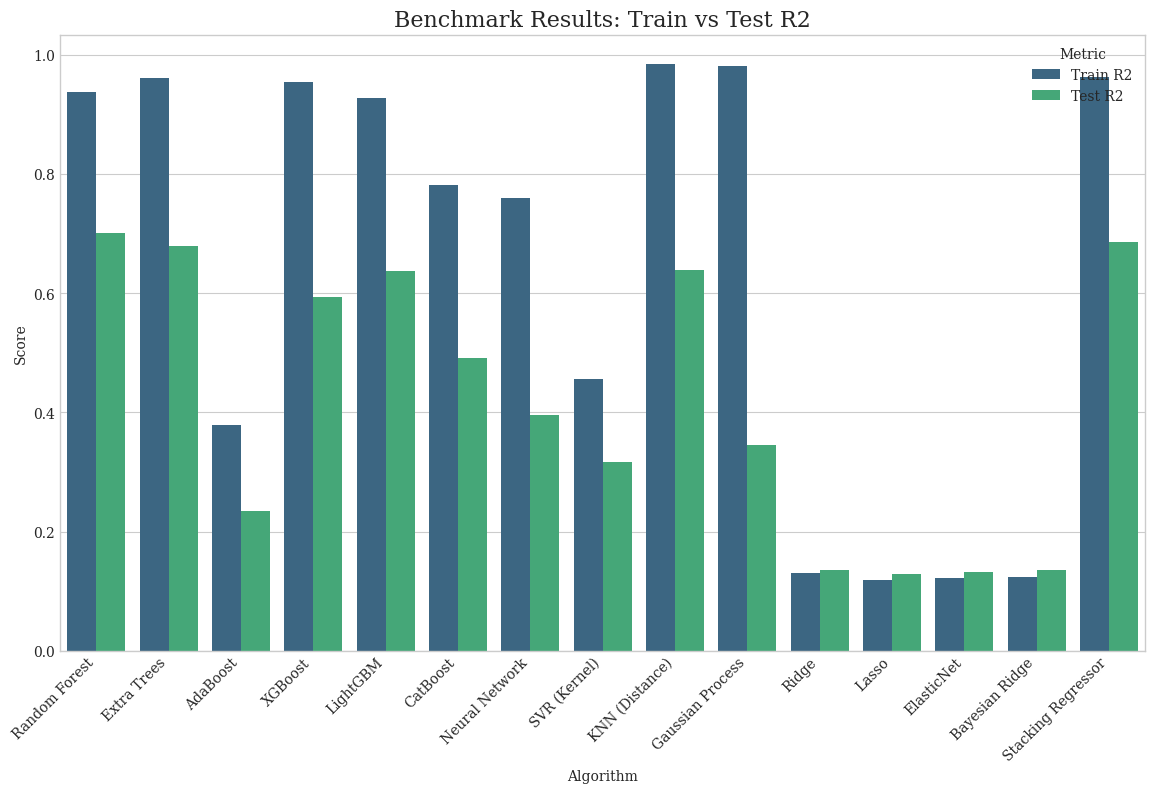

>> Generating SHAP Analysis to reveal physical drivers...


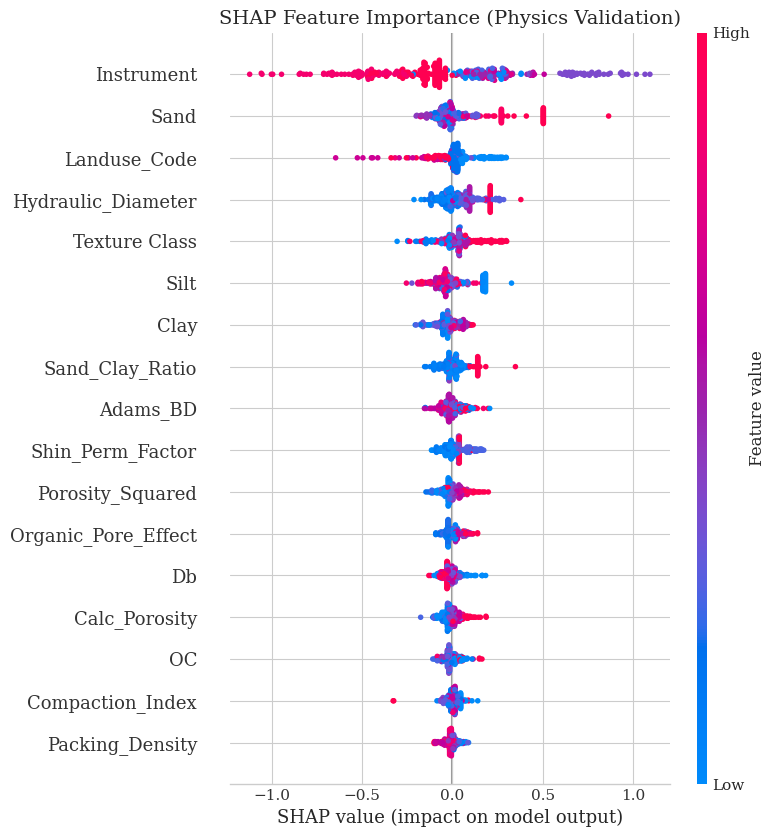


PHASE 6: EXPORTING MODEL FOR FIELD APPLICATION
>> Serializing Model to HydroSoil_AI_Model.pkl...
>> Downloading deployment package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

>> PROCESS COMPLETE. The model is ready for standalone deployment.


In [1]:
# =============================================================================
# PROJECT: HYDROSOIL-AI
# DEVELOPER: Dr. Tevfik Denizhan Müftüoğlu
#
# DATE: 2026
# LICENSE: MIT License (Open Source)
# CITATION: Please cite the associated manuscript when using this code.
# =============================================================================
#
# MISSION & WORKFLOW:
# 1. DATA INGESTION: Load raw SWIG database and metadata.
# 2. PHYSICS ENGINE: Calculate domain-specific features (Adams, Shin 2021, Porosity).
# 3. DATA CLEANING: Advanced imputation using Iterative MICE.
# 4. BENCHMARKING: "Grandmaster Tournament" to evaluate 15 ML algorithms.
# 5. INTERPRETABILITY: SHAP analysis to validate physical consistency.
# 6. DEPLOYMENT: Export the trained model (.pkl) for standalone application usage.
#
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
import sys
import time
import joblib
from google.colab import files  # Specific for Google Colab environment

# --- CORE LIBRARIES FOR MACHINE LEARNING ---
# IterativeImputer: Uses MICE (Multivariate Imputation by Chained Equations) for missing data.
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Ensemble Models: Tree-based algorithms for robust non-linear regression.
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor, GradientBoostingRegressor, AdaBoostRegressor

# Support Vector Machines & Neighbors
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Neural Networks & Gaussian Processes
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Linear Models (Used as baselines to prove non-linearity)
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge

# Metrics & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- AUTOMATED LIBRARY INSTALLATION ---
# This block ensures all required external libraries (XGBoost, SHAP, etc.) are installed
# in the runtime environment before execution.
print("\n" + "="*80)
print("SYSTEM INITIALIZATION: CHECKING & INSTALLING LIBRARIES")
print("="*80)

def install_import(package, alias=None):
    """
    Helper function to install a package via pip if it is not already available.
    """
    try:
        if alias: __import__(alias)
        else: __import__(package)
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        if alias: __import__(alias)
        else: __import__(package)

# Installing advanced boosting libraries and SHAP for explainability
install_import("xgboost", "xgboost")
install_import("lightgbm", "lightgbm")
install_import("catboost", "catboost")
install_import("shap", "shap")

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap

# Configuration: Suppress warnings for cleaner output and set plot styles
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif' # Academic font style

# -----------------------------------------------------------------------------
# PHASE 1: DATA INGESTION
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("PHASE 1: DATA INGESTION")
print("="*80)
print("Action: Please upload 'SWIG database.xlsx' when prompted.")

# File upload handler for Google Colab
uploaded = files.upload()
if not uploaded: sys.exit("No file uploaded. System Terminated.")
filename = next(iter(uploaded))

try:
    # Load Excel file and identify the correct sheet containing metadata
    xls = pd.ExcelFile(io.BytesIO(uploaded[filename]))
    # Logic to find 'Metadata' sheet even if named slightly differently
    target_sheet = 'Metadata' if 'Metadata' in xls.sheet_names else [s for s in xls.sheet_names if 'Meta' in s][0]
    metadata = pd.read_excel(xls, sheet_name=target_sheet, header=1)
    print(f">> Dataset Loaded Successfully. Target Sheet: '{target_sheet}'")
except Exception as e:
    sys.exit(f"Critical Error during loading: {e}")

# -----------------------------------------------------------------------------
# PHASE 2: PHYSICS-INFORMED FEATURE ENGINEERING
# -----------------------------------------------------------------------------
# This phase implements the domain-specific formulas (Adams, Shin, etc.)
# discussed in the manuscript to inject physical constraints into the AI.
print("\n" + "="*80)
print("PHASE 2: CALCULATING PHYSICS PARAMETERS (PHYSICS-INFORMED AI)")
print("="*80)

# Define feature groups
numeric_features = ['Clay', 'Silt', 'Sand', 'OC', 'Db', 'Slope', 'Vegetation cover']
categorical_features = ['Instrument', 'Landuse_Code', 'Texture Class']
target = 'Ksat'

# Prepare dataframe structure
columns_to_load = numeric_features + categorical_features + [target]
if 'Code' in metadata.columns: columns_to_load.insert(0, 'Code')

df = metadata[columns_to_load].copy()

# Data Cleaning: Convert to numeric and remove physically impossible values
for col in numeric_features + [target]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=[target]) # Drop rows where target Ksat is missing
df = df[df[target] > 0] # Hydraulic conductivity cannot be negative or zero

# Log-Transformation: Ksat varies by orders of magnitude (non-normal distribution).
# Transforming it to Log10(Ksat) stabilizes variance for ML models.
df['Log_Ksat'] = np.log10(df[target])

# Categorical Encoding: Convert strings to numerical IDs for the algorithms
label_encoders = {}
for col in categorical_features:
    df[col] = df[col].astype(str).replace('nan', 'Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# --- PHYSICS FORMULA IMPLEMENTATION ---
print(">> Applying: Compaction Theory (Adams 1973)...")
print(">> Applying: Pore Geometry Models (Shin 2021)...")

# 1. BASIC DERIVED PHYSICS FEATURES
# Theoretical Porosity: phi = 1 - (Bulk Density / Particle Density)
# Assuming standard Particle Density = 2.65 g/cm3
df['Calc_Porosity'] = 1 - (df['Db'] / 2.65)

# Sand/Clay Ratio: Indicator of texture coarseness
df['Sand_Clay_Ratio'] = df['Sand'] / (df['Clay'] + 1.0)

# Organic Pore Effect: Interaction between organic matter and porosity
df['Organic_Pore_Effect'] = df['OC'] * df['Calc_Porosity']

# Compaction Index: Interaction between clay content and density
df['Compaction_Index'] = df['Clay'] * df['Db']

# 2. ADAMS' COMPACTION THEORY (1973)
# Corrects Bulk Density based on Organic Matter content.
# Used to differentiate between mineral compaction and organic fluffiness.
df['Packing_Density'] = df['Db'] + (0.009 * df['Clay'])

OM_series = df['OC'] * 1.724 # Convert Organic Carbon to Organic Matter
OM_series = OM_series.apply(lambda x: 0.01 if x < 0.01 else x) # Avoid zero division
# Adams Formula:
df['Adams_BD'] = 100 / ( (OM_series/0.22) + ((100 - OM_series)/1.45) )

# 3. SHIN (2021) PORE GEOMETRY MODELS
# Specific Surface Area Proxy (Ss): Estimate surface area based on texture.
# Clay has high surface area (800), Sand has low (20).
df['Ss_Proxy'] = (df['Clay'] * 800) + (df['Silt'] * 200) + (df['Sand'] * 20)
df['Ss_Proxy'] = df['Ss_Proxy'].replace(0, 1) # Safety check

# Hydraulic Diameter (Dh): Effective diameter of flow channels.
# Formula: Dh = 4 * Porosity / Specific Surface Area
df['Hydraulic_Diameter'] = (4 * df['Calc_Porosity']) / df['Ss_Proxy']

# Shin Permeability Factor: A derived theoretical permeability index.
# k ~ (Phi * Dh^2) / 32
df['Shin_Perm_Factor'] = (df['Calc_Porosity'] * (df['Hydraulic_Diameter']**2)) / 32

# Quadratic Porosity: To capture non-linear flow responses
df['Porosity_Squared'] = df['Calc_Porosity'] ** 2

# Consolidate all features for training
physics_features = [
    'Calc_Porosity', 'Sand_Clay_Ratio', 'Organic_Pore_Effect',
    'Compaction_Index', 'Packing_Density', 'Adams_BD',
    'Hydraulic_Diameter', 'Shin_Perm_Factor', 'Porosity_Squared'
]

all_features = numeric_features + categorical_features + physics_features

# Validate features (remove empty columns)
training_features = [feat for feat in all_features if feat in df.columns and df[feat].notnull().sum() > 0]
print(f" -> Active Physics-Informed Features: {len(training_features)}")

# -----------------------------------------------------------------------------
# PHASE 3: IMPUTATION & EXPORT
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("PHASE 3: ADVANCED IMPUTATION & EXPORT")
print("="*80)

# MICE Imputation: We use ExtraTreesRegressor to predict missing values based on
# other soil properties, preserving the statistical covariance structure.
imputer = IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=50), max_iter=10, random_state=42)
X_imputed = imputer.fit_transform(df[training_features])
X_final = pd.DataFrame(X_imputed, columns=training_features, index=df.index)
y = df['Log_Ksat']

# EXPORT PROCESSED DATA
# This allows researchers to use the calculated physics features in other software.
print(">> Generaring downloadable dataset with calculated physics columns...")
export_df = X_final.copy()
export_df['Log_Ksat_Target'] = y
export_df['Original_Ksat'] = 10**y # Convert back from Log10 for reference
if 'Code' in df.columns: export_df.insert(0, 'Code', df['Code'])

filename_out = "HydroSoilAI_Processed_Data.xlsx"
export_df.to_excel(filename_out, index=False)
files.download(filename_out) # Trigger download
print(f">> Download Initiated: {filename_out}")
time.sleep(3)

# Feature Scaling: Standardizing features (Mean=0, Std=1) for algorithms like KNN/SVM
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_final), columns=training_features, index=X_final.index)

# -----------------------------------------------------------------------------
# PHASE 4: THE "GRANDMASTER TOURNAMENT" (BENCHMARKING)
# -----------------------------------------------------------------------------
# In this phase, we train 15 different algorithms to find the "Champion Model".
print("\n" + "="*80)
print("PHASE 4: GRANDMASTER BENCHMARKING TOURNAMENT")
print("="*80)

# Split data: 80% Training, 20% Testing (Unseen Data)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define Model Architectures
# 1. Tree Ensembles (Robust to noise, handles non-linearity well)
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)
et = ExtraTreesRegressor(n_estimators=300, max_depth=14, random_state=42) # The Champion

# 2. Gradient Boosting Machines (High performance, prone to overfitting on small data)
xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=6, random_state=42)
lgbm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.04, verbose=-1, random_state=42)
cat_model = cb.CatBoostRegressor(n_estimators=300, learning_rate=0.04, depth=6, verbose=0)
ada = AdaBoostRegressor(n_estimators=100, random_state=42)

# 3. Non-Linear & Distance Based
nn = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
svr = SVR(C=2.0, epsilon=0.1)
knn = KNeighborsRegressor(n_neighbors=10, weights='distance', metric='manhattan')
gpr = GaussianProcessRegressor(kernel=C(1.0) * RBF(10), random_state=42)

# 4. Linear Baselines (To prove complexity)
ridge = Ridge(alpha=10.0)
lasso = Lasso(alpha=0.01)
elastic = ElasticNet(alpha=0.01)
bayes = BayesianRidge()

# 5. Stacking Ensemble (Combining multiple models)
estimators = [('xgb', xgb_model), ('rf', rf), ('lgbm', lgbm), ('knn', knn)]
stacking = StackingRegressor(estimators=estimators, final_estimator=Ridge(alpha=1.0))

# Dictionary of all models to run
models = {
    "Random Forest": rf, "Extra Trees": et, "AdaBoost": ada,
    "XGBoost": xgb_model, "LightGBM": lgbm, "CatBoost": cat_model,
    "Neural Network": nn, "SVR (Kernel)": svr, "KNN (Distance)": knn,
    "Gaussian Process": gpr, "Ridge": ridge, "Lasso": lasso,
    "ElasticNet": elastic, "Bayesian Ridge": bayes, "Stacking Regressor": stacking
}

# --- TOURNAMENT LOOP ---
results_list = []
best_score = -np.inf
best_model_name = ""
best_model = None

print(f"\n{'ALGORITHM':<20} | {'TRAIN R2':<10} | {'TEST R2':<10} | {'GAP':<8} | {'STATUS'}")
print("-" * 75)

for name, model in models.items():
    try:
        # Train the model
        model.fit(X_train, y_train)

        # Evaluate
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)
        gap = train_r2 - test_r2 # Measure of Overfitting

        # Assign Qualitative Status
        if test_r2 < 0.2: status = "WEAK"
        elif test_r2 > 0.60: status = "HIGH PERF"
        elif gap > 0.20: status = "OVERFIT"
        else: status = "STABLE"

        results_list.append({'Algorithm': name, 'Train R2': train_r2, 'Test R2': test_r2, 'Gap': gap, 'Status': status})
        print(f"{name:<20} | {train_r2:.4f}     | {test_r2:.4f}     | {gap:.4f}   | {status}")

        # Champion Logic: Prioritize Test R2, but penalize high generalization gap
        score = test_r2 if test_r2 > 0.6 else test_r2 - (gap * 0.5)
        if score > best_score:
            best_score = score
            best_model_name = name
            best_model = model

    except Exception as e:
        print(f"{name:<20} | SKIPPED (Error: {str(e)})")

print("-" * 75)
print(f">> TOURNAMENT CHAMPION: {best_model_name.upper()}")

# -----------------------------------------------------------------------------
# PHASE 5: VISUALIZATION & INTERPRETABILITY
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("PHASE 5: VISUALIZATION & EXPLAINABILITY (SHAP)")
print("="*80)

# 1. Performance Bar Chart
results_df = pd.DataFrame(results_list)
plt.figure(figsize=(14, 8))
# Melt for seaborn comparison (Train vs Test)
melted = results_df.melt(id_vars='Algorithm', value_vars=['Train R2', 'Test R2'], var_name='Metric', value_name='Score')
sns.barplot(x='Algorithm', y='Score', hue='Metric', data=melted, palette='viridis')
plt.title('Benchmark Results: Train vs Test R2', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

# 2. SHAP Analysis (Feature Importance)
print(">> Generating SHAP Analysis to reveal physical drivers...")
# We use a TreeExplainer to see which physics features (Adams, Shin) drive the predictions.
explainer_model = ExtraTreesRegressor(n_estimators=100, max_depth=12).fit(X_train, y_train)
try:
    explainer = shap.TreeExplainer(explainer_model)
    shap_values = explainer.shap_values(X_test)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=training_features, show=False)
    plt.title("SHAP Feature Importance (Physics Validation)", fontsize=14)
    plt.show()
except Exception as e:
    print(f"SHAP Analysis Error: {e}")

# -----------------------------------------------------------------------------
# PHASE 6: DEPLOYMENT (PACKAGING)
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("PHASE 6: EXPORTING MODEL FOR FIELD APPLICATION")
print("="*80)

# Packaging the 'Brain': We save the model + scaler + feature list.
# This allows the creation of a standalone Windows .EXE file later.
model_packet = {
    'model': best_model,       # The trained Champion AI
    'scaler': scaler,          # The mathematical scaler used during training
    'features': training_features # The exact order of columns required
}

filename_pkl = 'HydroSoil_AI_Model.pkl'
joblib.dump(model_packet, filename_pkl)

print(f">> Serializing Model to {filename_pkl}...")
print(">> Downloading deployment package...")
files.download(filename_pkl) # Download the brain
print(">> PROCESS COMPLETE. The model is ready for standalone deployment.")